In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_blobs
from scipy.optimize import minimize
plt.style.use('ggplot')

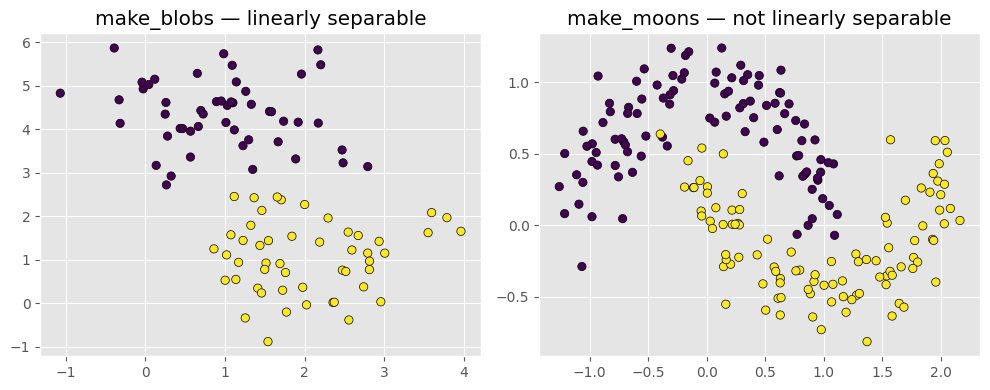

In [5]:
# SVM uses labels in {-1, +1}, not {0, 1}
X_blobs, y_raw = make_blobs(n_samples=100, centers=2, random_state=0, cluster_std=0.8)
y_blobs = np.where(y_raw == 0, -1, 1)

X_moons, y_raw = make_moons(n_samples=200, noise=0.15, random_state=0)
y_moons = np.where(y_raw == 0, -1, 1)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(X_blobs[:,0], X_blobs[:,1], c=y_blobs, edgecolor='k')
axes[0].set_title('make_blobs — linearly separable')
axes[1].scatter(X_moons[:,0], X_moons[:,1], c=y_moons, edgecolor='k')
axes[1].set_title('make_moons — not linearly separable')
plt.tight_layout()

## Support Vector Machine — geometric intuition

### What problem does SVM solve?

Given labelled points $\{(x_i, y_i)\}$ with $y_i \in \{-1, +1\}$, SVM finds the **hyperplane** $w \cdot x + b = 0$ that separates the two classes while **maximising the gap** (margin) between them.

### The decision function

For a point $x$, the **score** is:
$$f(x) = w \cdot x + b$$

- $f(x) > 0$ → predicted class $+1$
- $f(x) < 0$ → predicted class $-1$

The signed distance from $x$ to the hyperplane is $f(x) / \|w\|$.

### The margin

We normalise $w$ so that the closest points of each class satisfy $|f(x)| = 1$ (the **canonical hyperplanes**):

| Plane | Equation | Side |
|---|---|---|
| $w \cdot x + b = +1$ | positive support hyperplane | $y = +1$ |
| $w \cdot x + b = 0$ | decision boundary | — |
| $w \cdot x + b = -1$ | negative support hyperplane | $y = -1$ |

Distance between the two support hyperplanes:
$$\text{margin} = \frac{2}{\|w\|}$$

**Maximising the margin = minimising $\|w\|$.**

The points lying exactly on the support hyperplanes are called **support vectors** — they are the only points that actually define the boundary. All other training points could be removed and the solution would not change.

## Primal formulation and Hinge loss

### Hard-margin SVM (linearly separable data)

$$\min_{w,\, b} \;\frac{1}{2}\|w\|^2 \quad \text{s.t.} \quad y_i(w \cdot x_i + b) \geq 1 \;\;\forall i$$

Each constraint says: every point must be on the correct side of its support hyperplane.

### Soft-margin SVM (non-separable data)

We introduce **slack variables** $\xi_i \geq 0$ that allow some points to violate the margin:

$$\min_{w,\, b,\, \xi} \;\frac{1}{2}\|w\|^2 + C \sum_i \xi_i \quad \text{s.t.} \quad y_i(w \cdot x_i + b) \geq 1 - \xi_i,\;\; \xi_i \geq 0$$

$C$ controls the trade-off: **large $C$** = penalise violations heavily (narrow margin, few errors), **small $C$** = allow violations (wide margin, more errors).

### Hinge loss — eliminating the constraints

The optimal slack is $\xi_i = \max(0,\; 1 - y_i \cdot \text{score}_i)$. Substituting gives an **unconstrained** problem:

$$\boxed{L(w, b) = \underbrace{\frac{1}{2}\|w\|^2}_{\text{L2 regularisation}} + \;\frac{C}{B}\sum_i \underbrace{\max\!\left(0,\; 1 - y_i \cdot (w \cdot x_i + b)\right)}_{\ell_i\; =\; \text{hinge loss}}}$$

| $y_i \cdot \text{score}_i$ | $\ell_i$ | Interpretation |
|---|---|---|
| $\geq 1$ | $0$ | Well classified, outside margin — no penalty |
| $\in (0, 1)$ | $> 0$ | Correct side but inside margin — partial penalty |
| $\leq 0$ | $\geq 1$ | Wrong side — full penalty |

This is now a standard **unconstrained** optimisation — gradient descent applies directly.

## Gradient derivation — backward pass

### Setup

$$L = \frac{1}{2}\|w\|^2 + \frac{C}{B}\sum_{i=1}^B \max(0,\; 1 - y_i \cdot \underbrace{(w \cdot x_i + b)}_{\text{score}_i})$$

Define the **active set** $\mathcal{A} = \{i : 1 - y_i \cdot \text{score}_i > 0\}$ — examples that are on or past the margin and incur a penalty. Only these contribute a correction signal.

---

### Gradient w.r.t. $w$

For a single hinge term:
$$\frac{\partial \ell_i}{\partial w} = \begin{cases} -y_i x_i & \text{if } i \in \mathcal{A} \\ 0 & \text{otherwise} \end{cases}$$

Full gradient (L2 term + hinge term):
$$\boxed{\frac{\partial L}{\partial w} = \underbrace{w}_{\text{from L2}} \;-\; \frac{C}{B} \sum_{i \in \mathcal{A}} y_i x_i}$$

---

### Gradient w.r.t. $b$

$b$ does not appear in the L2 term:
$$\boxed{\frac{\partial L}{\partial b} = -\frac{C}{B} \sum_{i \in \mathcal{A}} y_i}$$

---

### Comparison with your neural network

| | **Linear SVM** | **NN `Linear` layer** |
|---|---|---|
| Weight gradient | $w - \frac{C}{B}\sum_{\mathcal{A}} y_i x_i$ | $X^T\, d_\text{out}$ |
| Structure | **identical** | **identical** |
| $d_\text{out}[i]$ | $-C\,y_i/B$ if $i \in \mathcal{A}$, else $0$ | $(\hat{y}_i - y_i)/B$ always |
| Gradient density | **sparse** — only support vectors contribute | **dense** — all examples contribute |
| Regularisation | explicit $\frac{1}{2}\|w\|^2$ in loss | implicit via Dropout / BatchNorm |

The update formula $\frac{\partial L}{\partial w} = X^T d_\text{out}$ is the same — the only difference is what $d_\text{out}$ looks like:
- **SVM**: zero for well-classified examples outside the margin, $-Cy_i/B$ otherwise
- **Cross-entropy**: $(\hat{y}_i - y_i)/B$ for every example without exception

In [6]:
# ── hinge loss ──────────────────────────────────────────────────────
def hinge_loss(scores, y, W, C):
    margins = np.maximum(0, 1 - y * scores)   # (B,) per-example hinge
    return 0.5 * (W @ W) + C * margins.mean()

# ── decision boundary ────────────────────────────────────────────────
def plot_svm_boundary(svm, X, y, title=''):
    x1 = np.linspace(X[:,0].min() - 0.5, X[:,0].max() + 0.5, 300)
    x2 = np.linspace(X[:,1].min() - 0.5, X[:,1].max() + 0.5, 300)
    xx1, xx2 = np.meshgrid(x1, x2)
    grid   = np.c_[xx1.ravel(), xx2.ravel()]
    scores = svm.decision_function(grid).reshape(xx1.shape)

    plt.contourf(xx1, xx2, scores > 0, alpha=0.2, cmap='RdBu')
    plt.contour(xx1, xx2, scores, levels=[-1, 0, 1],
                colors=['red', 'black', 'blue'],
                linestyles=['--', '-', '--'], linewidths=[1, 2, 1])
    plt.scatter(X[:,0], X[:,1], c=y, cmap='RdBu', edgecolor='k', zorder=3)

    if getattr(svm, 'support_vectors', None) is not None:
        plt.scatter(svm.support_vectors[:,0], svm.support_vectors[:,1],
                    s=200, facecolors='none', edgecolors='k', linewidths=2,
                    zorder=4, label=f'support vectors ({len(svm.support_vectors)})')
        plt.legend()
    if title:
        plt.title(title)

In [7]:
# ── linear SVM ──────────────────────────────────────────────────────
class LinearSVM:
    def __init__(self, C=1.0):
        self.C = C
        self.W = None
        self.b = 0.0

    def _init(self, n_features):
        self.W = np.zeros(n_features)
        self.b = 0.0

    def decision_function(self, X):
        return X @ self.W + self.b              # (B,) raw scores

    def backward(self, X, y, scores):
        B      = len(y)
        active = (1 - y * scores) > 0          # active hinge terms — the "support vectors" for this batch
        dW     = self.W.copy()                  # L2 gradient: ∂(½||w||²)/∂w = w
        db     = 0.0
        if active.any():
            dW -= self.C * (y[active, None] * X[active]).sum(axis=0) / B
            db -= self.C * y[active].sum() / B
        return dW, db

    def predict(self, X):
        return np.sign(self.decision_function(X))

    def score(self, X, y):
        return (self.predict(X) == y).mean()

In [8]:
# ── training loop ────────────────────────────────────────────────────
def train_svm(svm, X, y, lr=0.01, epochs=200, batch_size=32):
    svm._init(X.shape[1])
    n, history = len(X), []
    for _ in range(epochs):
        idx = np.random.permutation(n)
        epoch_loss, n_batches = 0.0, 0
        for i in range(0, n, batch_size):
            b      = idx[i:i+batch_size]
            scores = svm.decision_function(X[b])
            loss   = hinge_loss(scores, y[b], svm.W, svm.C)
            dW, db = svm.backward(X[b], y[b], scores)
            svm.W -= lr * dW
            svm.b -= lr * db
            epoch_loss += loss
            n_batches  += 1
        history.append(epoch_loss / n_batches)
    return history

Accuracy : 99.00%
||w||    : 0.532
Margin   : 3.761


/var/folders/cn/kt4mzqx94nscy_sncr2dpybc0000gn/T/ipykernel_9006/4088612515.py:13: RuntimeWarning: divide by zero encountered in matmul
  return X @ self.W + self.b              # (B,) raw scores
/var/folders/cn/kt4mzqx94nscy_sncr2dpybc0000gn/T/ipykernel_9006/4088612515.py:13: RuntimeWarning: overflow encountered in matmul
  return X @ self.W + self.b              # (B,) raw scores
/var/folders/cn/kt4mzqx94nscy_sncr2dpybc0000gn/T/ipykernel_9006/4088612515.py:13: RuntimeWarning: invalid value encountered in matmul
  return X @ self.W + self.b              # (B,) raw scores


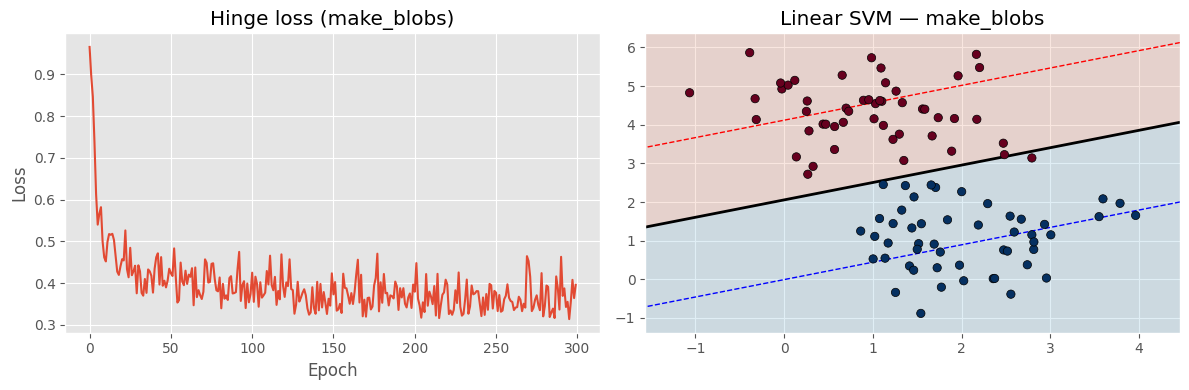

In [9]:
svm_lin = LinearSVM(C=1.0)
h = train_svm(svm_lin, X_blobs, y_blobs, lr=0.01, epochs=300)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(h)
axes[0].set(xlabel='Epoch', ylabel='Loss', title='Hinge loss (make_blobs)')
plt.sca(axes[1])
plot_svm_boundary(svm_lin, X_blobs, y_blobs, 'Linear SVM — make_blobs')
plt.tight_layout()

print(f'Accuracy : {svm_lin.score(X_blobs, y_blobs):.2%}')
print(f'||w||    : {np.linalg.norm(svm_lin.W):.3f}')
print(f'Margin   : {2 / np.linalg.norm(svm_lin.W):.3f}')

Accuracy: 79.00%  ← no straight line can separate the moons


/var/folders/cn/kt4mzqx94nscy_sncr2dpybc0000gn/T/ipykernel_9006/4088612515.py:13: RuntimeWarning: divide by zero encountered in matmul
  return X @ self.W + self.b              # (B,) raw scores
/var/folders/cn/kt4mzqx94nscy_sncr2dpybc0000gn/T/ipykernel_9006/4088612515.py:13: RuntimeWarning: overflow encountered in matmul
  return X @ self.W + self.b              # (B,) raw scores
/var/folders/cn/kt4mzqx94nscy_sncr2dpybc0000gn/T/ipykernel_9006/4088612515.py:13: RuntimeWarning: invalid value encountered in matmul
  return X @ self.W + self.b              # (B,) raw scores


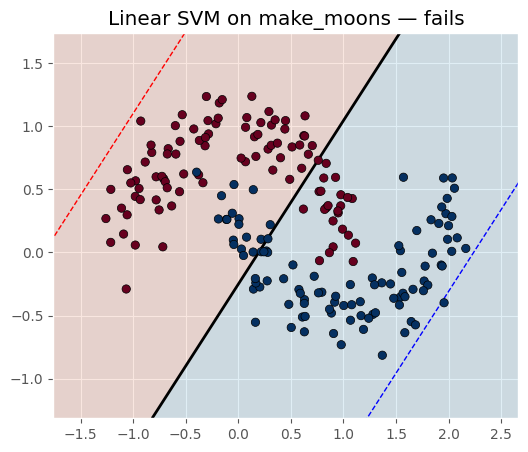

In [10]:
svm_fail = LinearSVM(C=1.0)
train_svm(svm_fail, X_moons, y_moons, lr=0.01, epochs=300)

plt.figure(figsize=(6, 5))
plot_svm_boundary(svm_fail, X_moons, y_moons, 'Linear SVM on make_moons — fails')
print(f'Accuracy: {svm_fail.score(X_moons, y_moons):.2%}  ← no straight line can separate the moons')

## Limitation and the Kernel trick

### The problem

A linear SVM only finds **linear boundaries**. `make_moons` is not linearly separable — no hyperplane separates the two crescents.

### Feature maps

One solution: **transform** the inputs into a higher-dimensional space $\phi(x)$ where the data *becomes* linearly separable, then run a linear SVM there.

$$x \in \mathbb{R}^d \;\xrightarrow{\phi}\; \phi(x) \in \mathbb{R}^D, \qquad D \gg d$$

**Example** — a circular boundary in 2D becomes a linear hyperplane in 3D:
$$\phi(x_1, x_2) = (x_1^2,\; \sqrt{2}\,x_1 x_2,\; x_2^2)$$
The circle $\{x : x_1^2 + x_2^2 = r^2\}$ maps to the plane $\{z : z_1 + z_3 = r^2\}$.

### The kernel trick

The SVM dual objective and decision function only need **dot products** $\phi(x_i) \cdot \phi(x_j)$. A **kernel function** computes this dot product *without ever computing $\phi$ explicitly*:

$$K(x_i, x_j) = \phi(x_i) \cdot \phi(x_j)$$

| Kernel | Formula | Implicit feature space |
|---|---|---|
| Linear | $x_i \cdot x_j$ | $\mathbb{R}^d$ — no transformation |
| Polynomial | $(1 + x_i \cdot x_j)^d$ | All monomials up to degree $d$ |
| RBF (Gaussian) | $\exp(-\gamma \|x_i - x_j\|^2)$ | $\infty$-dimensional |

The **RBF kernel** measures similarity: $K(x, z) \approx 1$ if $x \approx z$, $K(x, z) \approx 0$ if they are far apart. Its implicit feature space is infinite-dimensional — yet we never need to compute it.

$\gamma$ controls the width of the Gaussian: **large $\gamma$** = narrow similarity window (complex boundary), **small $\gamma$** = wide similarity window (smooth boundary).

## Dual formulation

### From primal to dual

Using Lagrange multipliers $\alpha_i \geq 0$ (one per training example), the constrained primal transforms into an equivalent **dual problem**:

$$\max_{\alpha} \;\sum_i \alpha_i - \frac{1}{2}\sum_{i,j} \alpha_i \alpha_j y_i y_j \underbrace{x_i \cdot x_j}_{\longrightarrow\; K(x_i,\, x_j)} \qquad \text{s.t.} \quad 0 \leq \alpha_i \leq C \;\;\forall i$$

Replacing $x_i \cdot x_j$ by $K(x_i, x_j)$ is exactly the kernel trick — the dual form makes it a natural substitution.

### Support vectors

At the optimum, $\alpha_i$ is non-zero only for examples on or inside the margin:

| $\alpha_i$ | Example type |
|---|---|
| $= 0$ | Correctly classified, outside margin — **not a support vector** |
| $\in (0, C)$ | Exactly on the margin — **margin support vector** |
| $= C$ | Inside margin or misclassified — **bound support vector** |

The decision function uses only support vectors:
$$f(x) = \sum_{i:\, \alpha_i > 0} \alpha_i\, y_i\, K(x_i, x) + b$$

This is **sparse** — a small fraction of training points typically have $\alpha_i > 0$.

### Recovering the bias

For any margin support vector $j$ (where $0 < \alpha_j < C$):
$$b = y_j - \sum_{i:\, \alpha_i > 0} \alpha_i y_i K(x_i, x_j)$$

In practice, average over all margin support vectors for numerical stability.

---

### Comparison: LinearSVM vs KernelSVM

| | **LinearSVM** | **KernelSVM** |
|---|---|---|
| Parameters stored | $w \in \mathbb{R}^d$ | $\{\alpha_i, y_i, x_i\}$ for each support vector |
| Prediction | $w \cdot x + b$ | $\sum \alpha_i y_i K(x_i, x) + b$ |
| Training | Gradient descent on $L(w,b)$ | Quadratic programming on $\alpha$ |
| Memory at test time | $O(d)$ | $O(n_{sv} \cdot d)$ |
| Non-linear boundary | No | Yes (with non-linear kernel) |

/var/folders/cn/kt4mzqx94nscy_sncr2dpybc0000gn/T/ipykernel_9006/3874392402.py:3: RuntimeWarning: divide by zero encountered in matmul
  return X1 @ X2.T
/var/folders/cn/kt4mzqx94nscy_sncr2dpybc0000gn/T/ipykernel_9006/3874392402.py:3: RuntimeWarning: overflow encountered in matmul
  return X1 @ X2.T
/var/folders/cn/kt4mzqx94nscy_sncr2dpybc0000gn/T/ipykernel_9006/3874392402.py:3: RuntimeWarning: invalid value encountered in matmul
  return X1 @ X2.T
/var/folders/cn/kt4mzqx94nscy_sncr2dpybc0000gn/T/ipykernel_9006/3874392402.py:9: RuntimeWarning: divide by zero encountered in matmul
  - 2 * X1 @ X2.T)
/var/folders/cn/kt4mzqx94nscy_sncr2dpybc0000gn/T/ipykernel_9006/3874392402.py:9: RuntimeWarning: overflow encountered in matmul
  - 2 * X1 @ X2.T)
/var/folders/cn/kt4mzqx94nscy_sncr2dpybc0000gn/T/ipykernel_9006/3874392402.py:9: RuntimeWarning: invalid value encountered in matmul
  - 2 * X1 @ X2.T)
/var/folders/cn/kt4mzqx94nscy_sncr2dpybc0000gn/T/ipykernel_9006/3874392402.py:13: RuntimeWarning

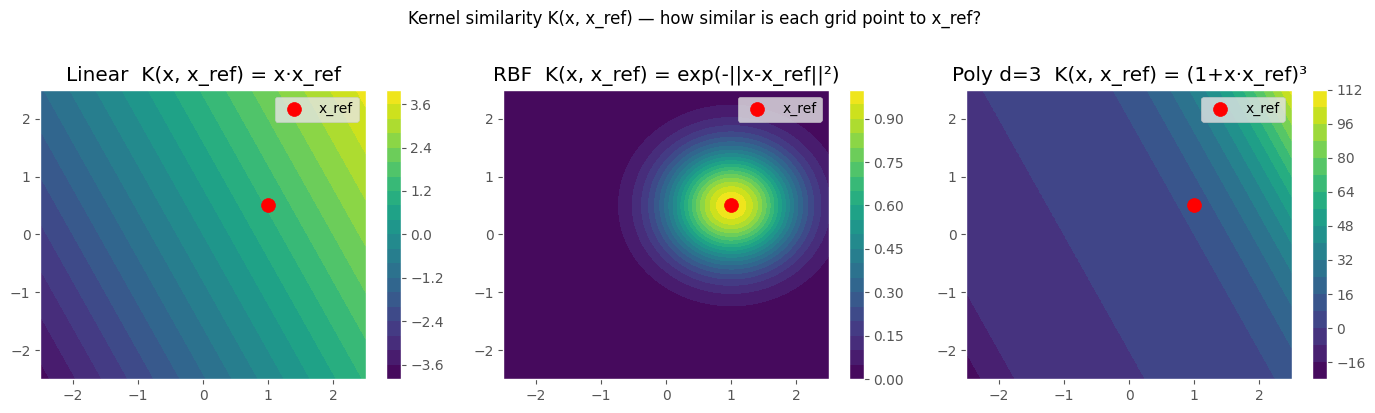

In [11]:
# ── kernel functions ────────────────────────────────────────────────
def kernel_linear(X1, X2):
    return X1 @ X2.T

def kernel_rbf(X1, X2, gamma=1.0):
    # ||x - z||² = ||x||² + ||z||² - 2 x·z  (avoids explicit loop)
    sq = (np.sum(X1**2, axis=1)[:,None]
        + np.sum(X2**2, axis=1)[None,:]
        - 2 * X1 @ X2.T)
    return np.exp(-gamma * np.clip(sq, 0, None))

def kernel_poly(X1, X2, degree=3):
    return (1 + X1 @ X2.T) ** degree

# ── visualise kernels : K(x, x_ref) as a function of x ──────────────
x_ref  = np.array([[1.0, 0.5]])
g      = np.linspace(-2.5, 2.5, 100)
xx, yy = np.meshgrid(g, g)
grid   = np.c_[xx.ravel(), yy.ravel()]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
configs = [
    ('Linear  K(x, x_ref) = x·x_ref',        kernel_linear(grid, x_ref).reshape(100,100)),
    ('RBF  K(x, x_ref) = exp(-||x-x_ref||²)', kernel_rbf(grid, x_ref, gamma=1.0).reshape(100,100)),
    ('Poly d=3  K(x, x_ref) = (1+x·x_ref)³', kernel_poly(grid, x_ref, degree=3).reshape(100,100)),
]
for ax, (name, K) in zip(axes, configs):
    im = ax.contourf(g, g, K, levels=20, cmap='viridis')
    ax.scatter(*x_ref[0], c='red', s=100, zorder=5, label='x_ref')
    ax.set_title(name); ax.legend()
    plt.colorbar(im, ax=ax)
plt.suptitle('Kernel similarity K(x, x_ref) — how similar is each grid point to x_ref?', y=1.02)
plt.tight_layout()

In [12]:
# ── kernel SVM (dual formulation) ───────────────────────────────────
class KernelSVM:
    def __init__(self, C=1.0, kernel='rbf', gamma=1.0, degree=3):
        self.C, self.kernel, self.gamma, self.degree = C, kernel, gamma, degree
        self.sv_alphas       = None
        self.support_vectors = None
        self.support_labels  = None
        self.b               = 0.0

    def _K(self, X1, X2):
        if self.kernel == 'linear': return kernel_linear(X1, X2)
        if self.kernel == 'rbf':    return kernel_rbf(X1, X2, self.gamma)
        if self.kernel == 'poly':   return kernel_poly(X1, X2, self.degree)

    def fit(self, X, y):
        n = len(X)
        K = self._K(X, X)                   # (n, n) Gram matrix
        Q = np.outer(y, y) * K              # Q_ij = yi yj K(xi, xj)

        # Dual: minimise ½ α^T Q α - 1^T α  (negated maximisation)
        def objective(a): return  0.5 * a @ Q @ a - a.sum()
        def gradient(a):  return  Q @ a - np.ones(n)

        result = minimize(objective, np.zeros(n), jac=gradient,
                          bounds=[(0, self.C)] * n, method='L-BFGS-B',
                          options={'maxiter': 2000, 'ftol': 1e-12})
        alphas = result.x

        sv_mask              = alphas > 1e-4
        self.support_vectors = X[sv_mask]
        self.support_labels  = y[sv_mask]
        self.sv_alphas       = alphas[sv_mask]

        # bias — average over margin support vectors (0 < α < C)
        margin_mask = sv_mask & (alphas < self.C - 1e-4)
        if margin_mask.any():
            K_m    = self._K(X[margin_mask], self.support_vectors)
            scores = (self.sv_alphas * self.support_labels) @ K_m.T
            self.b = np.mean(y[margin_mask] - scores)
        else:
            self.b = 0.0

    def decision_function(self, X):
        K = self._K(X, self.support_vectors)    # (n_test, n_sv)
        return (self.sv_alphas * self.support_labels) @ K.T + self.b

    def predict(self, X):
        return np.sign(self.decision_function(X))

    def score(self, X, y):
        return (self.predict(X) == y).mean()

Accuracy        : 99.50%
Support vectors : 20 / 200


/var/folders/cn/kt4mzqx94nscy_sncr2dpybc0000gn/T/ipykernel_9006/3874392402.py:9: RuntimeWarning: divide by zero encountered in matmul
  - 2 * X1 @ X2.T)
/var/folders/cn/kt4mzqx94nscy_sncr2dpybc0000gn/T/ipykernel_9006/3874392402.py:9: RuntimeWarning: overflow encountered in matmul
  - 2 * X1 @ X2.T)
/var/folders/cn/kt4mzqx94nscy_sncr2dpybc0000gn/T/ipykernel_9006/3874392402.py:9: RuntimeWarning: invalid value encountered in matmul
  - 2 * X1 @ X2.T)
/var/folders/cn/kt4mzqx94nscy_sncr2dpybc0000gn/T/ipykernel_9006/1456928958.py:21: RuntimeWarning: divide by zero encountered in matmul
  def objective(a): return  0.5 * a @ Q @ a - a.sum()
/var/folders/cn/kt4mzqx94nscy_sncr2dpybc0000gn/T/ipykernel_9006/1456928958.py:21: RuntimeWarning: overflow encountered in matmul
  def objective(a): return  0.5 * a @ Q @ a - a.sum()
/var/folders/cn/kt4mzqx94nscy_sncr2dpybc0000gn/T/ipykernel_9006/1456928958.py:21: RuntimeWarning: invalid value encountered in matmul
  def objective(a): return  0.5 * a @ Q @ 

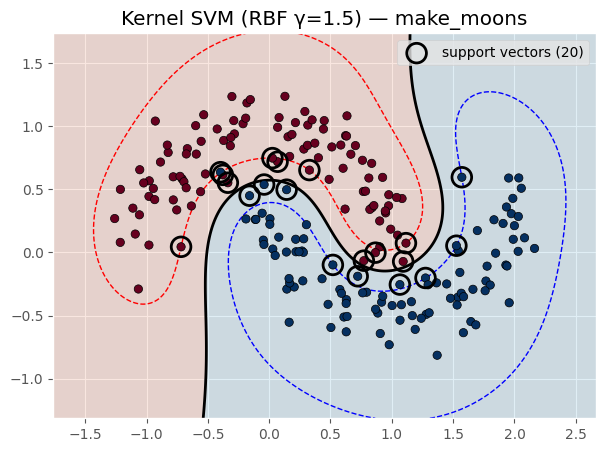

In [13]:
ksvm = KernelSVM(C=5.0, kernel='rbf', gamma=1.5)
ksvm.fit(X_moons, y_moons)

print(f'Accuracy        : {ksvm.score(X_moons, y_moons):.2%}')
print(f'Support vectors : {len(ksvm.support_vectors)} / {len(X_moons)}')

plt.figure(figsize=(7, 5))
plot_svm_boundary(ksvm, X_moons, y_moons, 'Kernel SVM (RBF γ=1.5) — make_moons')

/var/folders/cn/kt4mzqx94nscy_sncr2dpybc0000gn/T/ipykernel_9006/1456928958.py:21: RuntimeWarning: divide by zero encountered in matmul
  def objective(a): return  0.5 * a @ Q @ a - a.sum()
/var/folders/cn/kt4mzqx94nscy_sncr2dpybc0000gn/T/ipykernel_9006/1456928958.py:21: RuntimeWarning: overflow encountered in matmul
  def objective(a): return  0.5 * a @ Q @ a - a.sum()
/var/folders/cn/kt4mzqx94nscy_sncr2dpybc0000gn/T/ipykernel_9006/1456928958.py:21: RuntimeWarning: invalid value encountered in matmul
  def objective(a): return  0.5 * a @ Q @ a - a.sum()
/var/folders/cn/kt4mzqx94nscy_sncr2dpybc0000gn/T/ipykernel_9006/1456928958.py:22: RuntimeWarning: divide by zero encountered in matmul
  def gradient(a):  return  Q @ a - np.ones(n)
/var/folders/cn/kt4mzqx94nscy_sncr2dpybc0000gn/T/ipykernel_9006/1456928958.py:22: RuntimeWarning: overflow encountered in matmul
  def gradient(a):  return  Q @ a - np.ones(n)
/var/folders/cn/kt4mzqx94nscy_sncr2dpybc0000gn/T/ipykernel_9006/1456928958.py:22: 

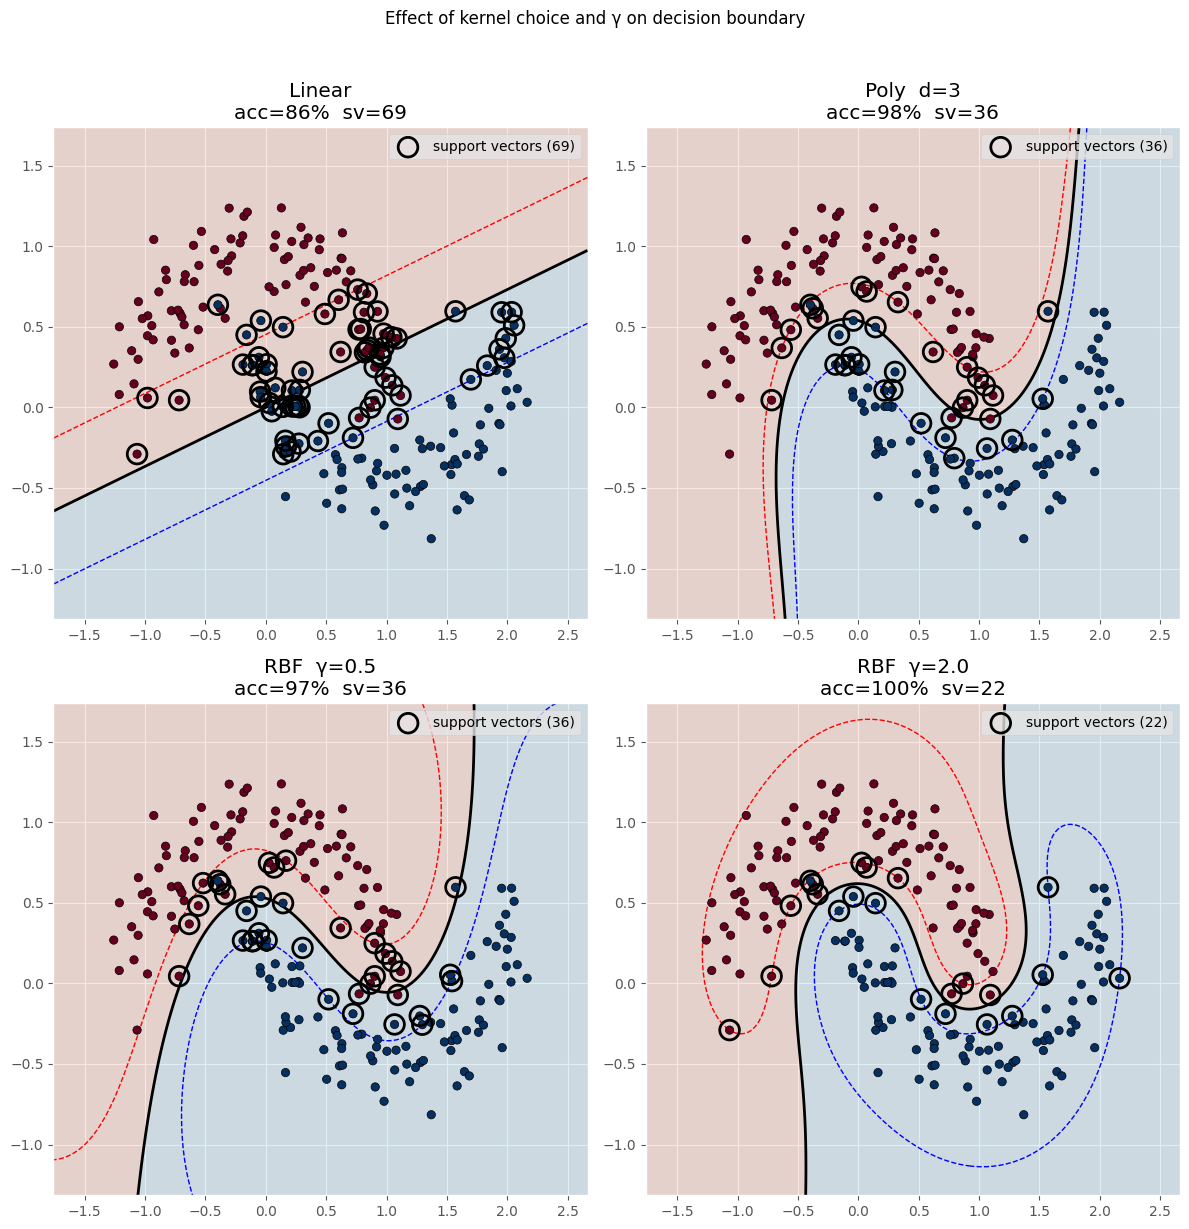

In [20]:
configs = [
    ('Linear',    dict(C=1.0, kernel='linear')),
    ('Poly  d=3', dict(C=1.0, kernel='poly',  degree=3)),
    ('RBF  γ=0.5',dict(C=5.0, kernel='rbf',   gamma=0.5)),
    ('RBF  γ=2.0',dict(C=5.0, kernel='rbf',   gamma=2.0)),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
for ax, (name, kwargs) in zip(axes.flatten(), configs):
    m = KernelSVM(**kwargs)
    m.fit(X_moons, y_moons)
    plt.sca(ax)
    plot_svm_boundary(m, X_moons, y_moons)
    ax.set_title(f'{name}\nacc={m.score(X_moons, y_moons):.0%}  sv={len(m.support_vectors)}')
plt.suptitle('Effect of kernel choice and γ on decision boundary', y=1.02)
plt.tight_layout()

## SVM vs Neural Network — when to use which

| | **SVM** | **Neural network (`nn.ipynb`)** |
|---|---|---|
| **Non-linearity** | Kernel trick (implicit, infinite-dim) | Stacked ReLU layers (explicit) |
| **Training** | Convex QP — **global optimum guaranteed** | Non-convex SGD — local optimum only |
| **Data regime** | Works well with **few examples** | Needs lots of data to shine |
| **Prediction cost** | $O(n_{sv} \cdot d)$ — grows with support vectors | $O(L \cdot d)$ — fixed by architecture |
| **Regularisation** | One hyperparameter: $C$ | Many (Dropout, BatchNorm, LR, ...) |
| **Interpretability** | Support vectors are meaningful | Weights are opaque |
| **Raw features** | Needs hand-crafted features or kernels | Learns features automatically |

### Why neural networks replaced SVMs for images / text / audio

The kernel trick only moves the problem to feature space — you still need to choose a kernel. For images, no one knows the right kernel; but a CNN learns it automatically from data. The non-convexity of neural network training turned out to be manageable in practice (SGD escapes bad local minima, BatchNorm / residual connections help gradients flow), while the kernel matrix $K \in \mathbb{R}^{n \times n}$ becomes prohibitively large for millions of training examples.